# Retrieval

In [1]:
import numpy as np # Used for return type and embeddings .
import open_clip # Used to load image embedding model  .
import torch # Used for device handling and tensor operations .
import os # Used for locating database storage .
from sentence_transformers import SentenceTransformer # Used to load text embedding model .
import chromadb # Used for vectorDB operations .
from typing import Dict # Used for datatype handling .
from dotenv import load_dotenv # Used for loading Huggingface api .
import os

In [2]:
load_dotenv() # For loading Huggingface api .

True

In [3]:
# Removing unwanted warnings from sentence transformers library .(Optional)
import warnings
from transformers import logging

logging.set_verbosity_error()
warnings.filterwarnings("ignore", message=".*position_ids.*UNEXPECTED.*")

In [4]:
# Used image embedding and query embedding .
class OpenClipTextEmbeddingModel:
     def __init__(self, model_name: str = "ViT-L-14", pretrained: str = "laion2b_s32b_b82k"):

        self.device="cuda" if torch.cuda.is_available() else "cpu" # Used to check if the machine has GPU if not assign CPU as device for working .
        self.model,self.preprocess,_=open_clip.create_model_and_transforms(
            model_name=model_name,
            pretrained=pretrained
        ) # Getting essential function from model .
        self.tokenizer=open_clip.get_tokenizer(model_name)
        self.model=self.model.to(self.device) # Device selection for model operations .
        self.model.eval() # Loading model

        # Displaying device on which model will run .
        if self.device=="cuda":
            print(f"OpenClip running on {torch.cuda.get_device_name(0)} .")
        else:
            print("OpenClip running on CPU .")
        print(f"Embedding dimensions of {model_name} is {open_clip.get_model_config(model_name).get('embed_dim')}")

     @torch.no_grad()
     def embed_query(self,query:str)->np.ndarray:
         if not query.strip():
             raise ValueError("Please give a valid prompt .")

         tokens=self.tokenizer([query]).to(self.device) # Used to convert into tensor .
         query_embedding=self.model.encode_text(tokens) # Embedding text or tensor value .
         query_embedding=query_embedding/query_embedding.norm(dim=-1,keepdim=True) # Normalizing values
         query_embedding=query_embedding.cpu().numpy()[0] # Converting tensor to numpy array .

         return query_embedding # Returning all the embeddings .

In [5]:
image_model=OpenClipTextEmbeddingModel()

OpenClip running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Embedding dimensions of ViT-L-14 is 768


In [6]:
# Used for text embedding and query embedding .
class BGETextEmbeddingModel:

    def __init__(self, model_name: str = "BAAI/bge-large-en-v1.5"):
        self.device="cuda" if torch.cuda.is_available() else "cpu" # Device check .
        self.model=SentenceTransformer(model_name_or_path=model_name,device=self.device) # Loading model .
        self.query_prefix="Represent this sentence for searching relevant passages: "
        if self.device=="cuda":
            print(f"BGE running on {torch.cuda.get_device_name(0)} .")
        else:
            print("BGE running on CPU .")
        print(f"Dimension of {model_name} is {self.model.get_sentence_embedding_dimension()}")

    @torch.no_grad()
    def embed_query(self,query:str)->np.ndarray:

        if not query.strip():
            raise ValueError("Given prompt is not valid .")

        query=self.query_prefix + query # Adding a prefix to prompt since BGE is instruction based embedding model .(Only for prompt not mandatory for documents)

        query_embedding=self.model.encode( # Embedding query .
            sentences=query,
            normalize_embeddings=True,
            convert_to_numpy=True
        )

        return query_embedding # Returning embedded values .

In [7]:
text_model=BGETextEmbeddingModel()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BGE running on NVIDIA GeForce RTX 3050 6GB Laptop GPU .
Dimension of BAAI/bge-large-en-v1.5 is 1024


In [8]:
class VectorStore:
    def __init__(self,collection_name:str,directory:str="../data/database"):
        self.collection_name=collection_name # Collection name .
        self.persistent_directory=directory # Directory to store database .
        self.collection=None # Collection , used to store data .
        self.client=None # Used to connect database .
        self.initialize_store() # Initializing vectordb .

    def initialize_store(self):
            try:
                os.makedirs(name=self.persistent_directory,exist_ok=True) # Checking if directory exists ,if not creating one .
                self.client=chromadb.PersistentClient(path=self.persistent_directory)

                if self.collection_exists(self.collection_name): # Checking if the collection exists , if collection exists then loading it .
                    print(f"Loading collection {self.collection_name} from database .")
                    self.collection=self.client.get_collection(self.collection_name)

                else: # If collection does not exist then creating it .
                    print(f"New collection {self.collection_name} created in database .")
                    self.collection=self.client.create_collection(self.collection_name)

                print(f"Vector store initialized .") # Success message is vector store initialized .
                print(f"Existing documents in collection {self.collection.count()}")

            except Exception as e: # Exception handling .
                raise RuntimeError("Could not initialize vector store .") from e
    # The following function is used to check if the collection exists .
    def collection_exists(self,collection_name:str)->bool:
        collection_in_db=self.client.list_collections()
        return any(col.name==collection_name for col in collection_in_db )

    # The following function is used get queries and get relevant documents
    def query(self,query_embedding:np.ndarray,k:int=5,where:Dict | None=None):

        if not self.collection: # Checking if collection is initialized .
            raise RuntimeError("Collection is not initialized .")

        if query_embedding.ndim!=1: # Checking if query is single dimension .
            raise ValueError("Query embedding must be a 1D vector .")

        results=self.collection.query( # Embedding query .
            query_embeddings=[query_embedding.tolist()],
            n_results=k,
            where=where,
            include=["documents","metadatas","distances"]
        )
        return results # Returning results .

In [9]:
image_vector_store=VectorStore(collection_name="OpenClip_embeddings") # Using existing data from database .

Loading collection OpenClip_embeddings from database .
Vector store initialized .
Existing documents in collection 69


In [10]:
text_vector_store=VectorStore(collection_name="BGE_embeddings") # Using existing data from database .

Loading collection BGE_embeddings from database .
Vector store initialized .
Existing documents in collection 123


In [11]:
from sentence_transformers import CrossEncoder
from typing import List,Optional
from time import perf_counter

In [12]:
# Used to rerank the chunks with relevance .
class Reranker:
    def __init__(self):
        self.model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-12-v2")
        print("Reranker initialized")

    def rerank(self, query: str, items: List[Dict], top_k: int = 3) -> List[Dict]:
        if not items:  # Checking if chunks are empty.
            return []

        pairs = [[query, item["text"]] for item in items]
        scores = self.model.predict(pairs)  # Reranking distances.

        ranked = sorted(  # Ranking based on score.
            zip(items, scores),
            key=lambda x: x[1],
            reverse=True  # Higher score is better.
        )

        return [item for item, _ in ranked[:top_k]]  # Returning top k chunks.

In [13]:
from PIL import Image
import os
from typing import List,Dict,Optional

In [14]:
# Used to format retrieved docs from retrieval output .
class ContextFormatter:
    def __init__(self, max_text_chunks: int = 3, max_images: int = 1, text_distance_threshold: float = 0.55, image_distance_threshold: float = 0.65):
        if not isinstance(max_text_chunks, int) or max_text_chunks <= 0:  # Threshold value validation.
            raise ValueError(f"max_text_chunks must be a positive integer, got {max_text_chunks}.")

        if not isinstance(max_images, int) or max_images <= 0:
            raise ValueError(f"max_images must be a positive integer, got {max_images}.")

        if not isinstance(text_distance_threshold, (int, float)) or text_distance_threshold < 0:
            raise ValueError(f"text_distance_threshold must be a non-negative number, got {text_distance_threshold}.")

        if not isinstance(image_distance_threshold, (int, float)) or image_distance_threshold < 0:
            raise ValueError(f"image_distance_threshold must be a non-negative number, got {image_distance_threshold}.")

        self.max_text_chunks = max_text_chunks  # Limiting number of chunks.
        self.max_images = max_images  # Limiting number of max images.
        self.text_distance_threshold = float(text_distance_threshold)  # Threshold for filtering chunks (lowered for quality).
        self.image_distance_threshold = float(image_distance_threshold)  # Threshold for filtering images (lowered for quality).

    # Removing unwanted details from results.
    def _flatten_results(self, results: Dict) -> List[Dict]:
        if not results or not isinstance(results, Dict):  # Checking if data is empty.
            return []

        documents = results.get("documents", [[]])[0]
        metadatas = results.get("metadatas", [[]])[0]
        distances = results.get("distances", [[]])[0]

        min_length = min(len(documents), len(metadatas), len(distances))
        if min_length == 0:
            return []

        flattened = []
        for i in range(min_length):
            flattened.append({  # Appending required data.
                "text": documents[i],
                "metadata": metadatas[i],
                "distance": float(distances[i])
            })

        return flattened  # Returning flattened data.

    # The following function is used to load image from path.
    def _load_image(self, image_path: str) -> Optional[Image.Image]:
        if not image_path or not isinstance(image_path, str):  # Checking if image path is valid.
            return None

        if not os.path.exists(image_path):
            print(f"Warning: Image path does not exist: {image_path}")
            return None

        try:
            return Image.open(image_path).convert("RGB")  # Returning loaded image.
        except Exception as e:
            print(f"Failed to load image {image_path}: {e}")
            return None

    # The following function filters text chunks based on distance.
    def _select_text_chunks(self, text_results: Dict) -> List[Dict]:
        items = self._flatten_results(text_results)  # Removing unwanted data from results.

        if not items:  # Checking if items is empty.
            return []

        filtered = [
            i for i in items
            if i["distance"] <= self.text_distance_threshold  # Filtering based on distance.
        ]

        if not filtered:  # If no chunks (all distances greater than threshold), return top retrieved.
            items.sort(key=lambda x: x["distance"])
            return items[:self.max_text_chunks]  # Returning max number of chunks.

        filtered.sort(key=lambda x: x["distance"])
        return filtered[:self.max_text_chunks]  # Returning filtered chunks.

    # The following function is to format text in data.
    def _format_text_context(self, text_items: List[Dict]) -> str:
        if not text_items or not isinstance(text_items, list):  # Input validation.
            return ""

        lines = []

        for idx, item in enumerate(text_items, start=1):  # Fetching required data.
            if not isinstance(item, dict):
                continue

            meta = item["metadata"] or {}
            source = meta.get("source", "unknown")
            page = meta.get("page_num", "N/A")

            text = item["text"].strip()

            if not text:
                continue

            lines.append(
                f"[{idx}] {text}\n"
                f"(Source: {source}, page {page})"  # Attaching source and page number.
            )

        return "\n\n".join(lines)  # Returning formatted text.

    # The following function selects images from retrieved output.
    def _select_images(self, image_results: Dict) -> List[Dict]:
        items = self._flatten_results(image_results)  # Removing unwanted data from results.

        if not items:
            return []

        items = [
            i for i in items
            if i["distance"] <= self.image_distance_threshold  # Filtering based on distance.
        ]

        items.sort(key=lambda x: x["distance"])
        return items[:self.max_images]  # Returning filtered output.

    # The following function is used to format image caption.
    def _format_image_context(self, image_items: List[Dict]) -> List[Dict]:
        if not image_items or not isinstance(image_items, list):
            return []

        formatted_images = []

        for item in image_items:  # Fetching required data.
            if not isinstance(item, dict):
                continue

            meta = item.get("metadata") or {}
            image_path = meta.get("image_path")
            caption = meta.get("caption_text", "").strip()

            image = self._load_image(image_path)  # Loading image.
            if image is None:  # Checking if image is not empty.
                continue

            formatted_images.append({  # Attaching image and its caption.
                "image": image,
                "caption": caption
            })

        return formatted_images  # Returning formatted images.

    # The following function is to format both text and images.
    def format(self, retrieval_output: Dict) -> Dict:
        if not retrieval_output or not isinstance(retrieval_output, dict):
            raise ValueError("retrieval_output must be a non-empty dictionary.")

        query = retrieval_output.get("query", "")  # Fetching query.

        text_items = self._select_text_chunks(
            retrieval_output.get("text_results", {})  # Selecting text chunks.
        )

        image_items = self._select_images(
            retrieval_output.get("image_results", {})  # Selecting images.
        )

        return {  # Returning filtered text and images.
            "query": query,
            "text_context": self._format_text_context(text_items),
            "images": self._format_image_context(image_items)
        }

In [15]:
# Used to retrieve documents from database using input query from user .
class RetrievalRag:
    def __init__(self, image_embedder: OpenClipTextEmbeddingModel, text_embedder: BGETextEmbeddingModel, image_vectordb: VectorStore, text_vectordb: VectorStore, use_reranker: bool = True, formatter: Optional[ContextFormatter] = None):
        self.image_embedder = image_embedder  # Image embedding model.
        self.text_embedder = text_embedder  # Text embedding model.
        self.image_vectordb = image_vectordb  # Image database.
        self.text_vectordb = text_vectordb  # Text database.
        self.reranker = Reranker() if use_reranker else None
        self.formatter = formatter or ContextFormatter()

    # The following function is used to retrieve text from database.
    def retrieve_text(self, query: str, k: int = 5) -> Dict:
        if not query or not query.strip():  # Query validation.
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")

        start_total = perf_counter() # Start time before the retrieval .

        start_embed=perf_counter()
        query_embedding = self.text_embedder.embed_query(query)  # Embedding query.
        embed_time=perf_counter() - start_embed # Calculate query embedding time .

        start_query=perf_counter()
        results = self.text_vectordb.query(query_embedding=query_embedding, k=k)
        query_time=perf_counter()-start_query # Calculate retrieval time .

        total_time=perf_counter() -start_total # Calculate total time .

        results["retrieval_metrics"]={
            "text_embed_time":round(embed_time,4),
            "text_search_time":round(query_time,4),
            "text_total_retrieval_time":round(total_time,4)
        }
        return results  # Returning top k results.

    # The following function is used to retrieve images and their captions from database.
    def retrieve_images(self, query: str, k: int = 3) -> Dict:
        if not query or not query.strip():  # Query validation.
            raise ValueError("Query must be a non-empty string.")

        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be a positive integer, got {k}.")


        start_total = perf_counter() # Start time before the retrieval .

        start_embed=perf_counter()
        query_embedding = self.image_embedder.embed_query(query)  # Embedding query.
        embed_time=perf_counter() - start_embed # Calculate query embedding time .

        start_query=perf_counter()
        results = self.image_vectordb.query(
            query_embedding=query_embedding, k=k
        )
        query_time=perf_counter()-start_query # Calculate retrieval time .

        total_time=perf_counter() -start_total # Calculate total time .

        results["retrieval_metrics"]={
            "image_embed_time":round(embed_time,4),
            "image_search_time":round(query_time,4),
            "image_total_retrieval_time":round(total_time,4)
        }

        return results

    # Used to retrieve multimodal data.
    def retrieve(self, query: str, text_k: int = 10, image_k: int = 5, rerank_k: int = 5) -> Dict:
        if not query or not query.strip():  # Checking if query is valid.
            raise ValueError("Query must be non-empty string.")

        if not isinstance(text_k, int) or text_k <= 0:  # Threshold validation.
            raise ValueError(f"text_k must be a positive integer, got {text_k}.")

        if not isinstance(image_k, int) or image_k <= 0:
            raise ValueError(f"image_k must be a positive integer, got {image_k}.")

        start_total=perf_counter() # Start time before retrieval of images and text . M3 (Retrieval time)

        text_results = self.retrieve_text(query=query, k=text_k)

        image_results = self.retrieve_images(query=query, k=image_k)

        # For quality: Boost text chunk scores if they have related images retrieved.
        text_items = self.formatter._flatten_results(text_results)
        image_ids = [i["metadata"].get("image_path", "").split('/')[-1] for i in self.formatter._flatten_results(image_results)]  # Extract retrieved image IDs.
        for item in text_items:
            related_ids = item["metadata"].get("related_image_ids", [])
            overlap = set(related_ids) & set(image_ids)
            if overlap:
                item["distance"] *= 0.9  # Boost (lower distance) if overlap for hybrid quality.

        if self.reranker:  # Checking if reranking is initialized.
            reranked = self.reranker.rerank(
                query=query,
                items=text_items,
                top_k=min(rerank_k, len(text_items)),
            )

            # Rebuild results in original structure.
            text_results["documents"] = [[i["text"] for i in reranked]]
            text_results["metadatas"] = [[i["metadata"] for i in reranked]]
            text_results["distances"] = [[i["distance"] for i in reranked]]

        overall_time=perf_counter() - start_total # Calculate overall time .

        # Overall retrieval time stats .
        combined_metrics={
            "overall_retrieval_time":overall_time,
            "text_metrics":text_results.get("retrieval_metrics"),
            "image_metrics":image_results.get("retrieval_metrics")
        }

        return {  # Returning retrieved documents from database.
            "query": query,
            "text_results": text_results,
            "image_results": image_results,
            "retrieval_metrics":combined_metrics
        }

In [16]:
formatter=ContextFormatter() # Initializing context formatter .

In [17]:
retrieval=RetrievalRag(image_embedder=image_model,text_embedder=text_model,image_vectordb=image_vector_store,text_vectordb=text_vector_store,use_reranker=True,formatter=formatter) # Initializing required variables .

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Reranker initialized


In [18]:
retrieved_docs = retrieval.retrieve("Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?",text_k=8,rerank_k=3) # Test question .

In [19]:
print(retrieved_docs.keys()) # Getting output keys .

dict_keys(['query', 'text_results', 'image_results', 'retrieval_metrics'])


In [20]:
print(retrieved_docs)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_results': {'ids': [['b7e75db9cd299b7fddb8b5378246d8fa5e48eea4f003b4ac5487154546683d5c', 'f6bf863b28353816137e63a3498153b8ba0cbd9a3d3896f67457b9e36de5ebee', 'a594106ed14b3e0b5b488afa3782879c524604105612e7c0b1644c904a33413c', 'd511139a83a69e61dd55c9334287f4c28b710c298c9e225dbe8970a9dbfdb176', '869de25f24203ea855ac8e9420e26dd1e82f11461b7e0bbbebec30c10d5d87e7', 'fa7f77d32b642fee7691f48280704b0698c7dd37fb1bd12cb2f22c1f13039b21', '71bc166e9a136292d8fe1f2a30bc071f3bc37ba86b96b28988fce03f8daa1f99', '6274aa46648770278624175a49604c9dd31b79e8ce4dee106865bdaee7463062']], 'embeddings': None, 'documents': [['VIIRS also has a day/night band to detect low levels of visible/near-infrared radiance at night \nfrom sources on or near the Earth’s surface, such as low clouds, fog and snow cove

In [21]:
from json import dumps

In [22]:
print(dumps(retrieved_docs.get("retrieval_metrics"),sort_keys=False,indent=True)) # Pretty print .

{
 "overall_retrieval_time": 3.2599120999984734,
 "text_metrics": {
  "text_embed_time": 0.4639,
  "text_search_time": 0.0193,
  "text_total_retrieval_time": 0.4832
 },
 "image_metrics": {
  "image_embed_time": 0.0429,
  "image_search_time": 0.0113,
  "image_total_retrieval_time": 0.0541
 }
}


In [23]:
formatted=formatter.format(retrieval_output=retrieved_docs)
context=formatted["text_context"]
images=formatted["images"]

In [24]:
print(formatted)

{'query': 'Based on Hubble observations, how did the visual evolution of Type Ia supernova host galaxies across redshift provide evidence against dust extinction as the primary cause of their observed dimming?', 'text_context': '[1] VIIRS also has a day/night band to detect low levels of visible/near-infrared radiance at night \nfrom sources on or near the Earth’s surface, such as low clouds, fog and snow cover illuminated by \nmoonlight and lightning flashes. This marks a significant advance over current imagers ability to aid \nrecovery efforts. For the first time, there will be calibrated visible observations of clouds and other \nphenomena at night.\nNPP’s Clouds and the Earth’s Radiant Energy System (CERES) instrument uses events like a volcanic \neruption or a massive wildfire to help researchers understand how the overall Earth’s radiation budget \nresponds to short-term events. The Ozone Mapping and Profiler Suite (OMPS) tracks emissions \nfrom events like volcanic eruptions by

In [25]:
print(context)

[1] VIIRS also has a day/night band to detect low levels of visible/near-infrared radiance at night 
from sources on or near the Earth’s surface, such as low clouds, fog and snow cover illuminated by 
moonlight and lightning flashes. This marks a significant advance over current imagers ability to aid 
recovery efforts. For the first time, there will be calibrated visible observations of clouds and other 
phenomena at night.
NPP’s Clouds and the Earth’s Radiant Energy System (CERES) instrument uses events like a volcanic 
eruption or a massive wildfire to help researchers understand how the overall Earth’s radiation budget 
responds to short-term events. The Ozone Mapping and Profiler Suite (OMPS) tracks emissions 
from events like volcanic eruptions by measuring not only ozone, but also sulfur dioxide and airborne 
particles called aerosols. The combination of two NPP instruments, the Cross-track Infrared Sounder 
(CrIS) and the Advanced Technology Microwave Sounder (ATMS) instruments

In [26]:
print(images)

[{'image': <PIL.Image.Image image mode=RGB size=956x599 at 0x1A767142800>, 'caption': 'MODIS Red-Green-Blue Characterization\nMODIS True Color'}]


In [27]:
TEST_QUESTIONS = [
    # ======================
    # SECTION 1: VOYAGER GRAND TOUR (Questions 1-8)
    # ======================
    {
        "id": 1,
        "type": "temporal_trajectory_reasoning",
        "question": "Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Left diagram showing flight paths of Voyager 1 and 2 through outer solar system"},
        "required_context": {"pages": [1], "focus": "Introduction and flight trajectories explanation including gravity assists and Titan flyby trade-off"}
    },
    {
        "id": 2,
        "type": "counterintuitive_scale_perspective",
        "question": "Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Left image: First photograph of Earth-Moon system in single frame"},
        "required_context": {"pages": [2], "focus": "Text describing the first Earth-Moon photo and its distance of 7.25 million miles"}
    },
    {
        "id": 3,
        "type": "visual_evidence_vs_claim",
        "question": "What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Left montage: Jupiter and its four largest moons (not to scale)"},
        "required_context": {"pages": [3], "focus": "Discoveries at Jupiter including Io volcanoes, Europa ice surface, and new small moons"}
    },
    {
        "id": 4,
        "type": "philosophical_visual_synthesis",
        "question": "Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?",
        "expected_images": True,
        "image_reference": {"page": 4, "position": "Bottom image: Family Portrait of six planets from 6 billion km"},
        "required_context": {"pages": [4], "focus": "Text about the Family Portrait mosaic and camera shutdown for power conservation"}
    },
    {
        "id": 5,
        "type": "artifact_inference",
        "question": "Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?",
        "expected_images": True,
        "image_reference": {"page": 5, "position": "Both images: Golden Record with cover and contents"},
        "required_context": {"pages": [5], "focus": "Description of Golden Record contents, playback instructions, and stylus"}
    },
    {
        "id": 6,
        "type": "trajectory_decision_reasoning",
        "question": "What scientific trade-off led to Voyager 1's flyby permanently sacrificing all future planetary encounters while Voyager 2 was allowed to continue?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Right montage: Saturn and several of its moons (not to scale)"},
        "required_context": {"pages": [3], "focus": "Discoveries at Saturn including Titan lakes, rings complexity, and new satellites"}
    },
    {
        "id": 7,
        "type": "discovery_density_reasoning",
        "question": "Why is it counterintuitive that Voyager 2 discovered more new moons at these distant ice giants than at Jupiter and Saturn combined, despite spending far less time observing them?",
        "expected_images": True,
        "image_reference": {"page": 4, "position": "Left and right montages: Uranus with moons and Neptune with Triton"},
        "required_context": {"pages": [4], "focus": "Discoveries at Uranus and Neptune including new moons, magnetic fields, and Triton geysers"}
    },
    {
        "id": 8,
        "type": "long_duration_philosophy",
        "question": "How does the visible design explain why both spacecraft could still be operating after 45+ years when most missions are planned for only a few years?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Right image: Voyager spacecraft as it appears in space"},
        "required_context": {"pages": [2, 5], "focus": "Spacecraft description and interstellar mission with power projections to 2025"}
    },

    # ======================
    # SECTION 2: CURIOSITY / MARS SCIENCE LABORATORY (Questions 9-16)
    # ======================
    {
        "id": 9,
        "type": "geological_narrative_reconstruction",
        "question": "Reconstruct the full ancient river system story and explain why this image alone was not sufficient to prove past habitability.",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Top-left image: Rock outcrop called Link with rounded pebbles"},
        "required_context": {"pages": [2], "focus": "Text about evidence for stream flow and conglomerate rocks"}
    },
    {
        "id": 10,
        "type": "engineering_precision_causality",
        "question": "Why was the 20 km landing precision improvement not just an engineering achievement but a fundamental prerequisite for the entire scientific mission?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Top-right image: Curiosity lowered by sky crane"},
        "required_context": {"pages": [1], "focus": "Mission Overview including landing technology and site selection"}
    },
    {
        "id": 11,
        "type": "self_portrait_technical_reasoning",
        "question": "How was this image technically assembled, and what does it reveal about the rover's mobility and self-diagnostic capabilities?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Top-left image: Curiosity self-portrait"},
        "required_context": {"pages": [3], "focus": "Text about rover size and design inheritance from Spirit/Opportunity"}
    },
    {
        "id": 12,
        "type": "drill_evidence_inference",
        "question": "How does the powdered interior sample, combined with the 4.2 billion year age, create a paradox about geological preservation on Mars?",
        "expected_images": True,
        "image_reference": {"page": 2, "position": "Bottom-right image: First sample drilling at John Klein"},
        "required_context": {"pages": [2], "focus": "Text about drilled sample analysis and rock age determination"}
    },
    {
        "id": 13,
        "type": "power_system_counterintuitive",
        "question": "Why was the documented decline in radioisotope power from 110W to 100W over two years actually a positive indicator for long-term mission success?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Center image: Big rover illustration or context"},
        "required_context": {"pages": [3], "focus": "Text about radioisotope power system and decline"}
    },
    {
        "id": 14,
        "type": "habitability_hierarchy",
        "question": "Why does the document argue that visual imaging alone could never have proven past habitability, and what hierarchical chain of instruments was required?",
        "expected_images": True,
        "image_reference": {"page": 3, "position": "Center image: Rover with Mast Camera and ChemCam"},
        "required_context": {"pages": [3], "focus": "Text about science payload and instruments"}
    },
    {
        "id": 15,
        "type": "landing_site_synthesis",
        "question": "Why was Gale Crater chosen over dozens of other sites, and how did the payload directly address the habitability question?",
        "expected_images": True,
        "image_reference": {"page": 1, "position": "Bottom image: Gale Crater size comparison"},
        "required_context": {"pages": [1], "focus": "Text about landing site and crater size"}
    }
]

In [28]:
from typing import List, Dict

In [29]:
def retrieve_test_questions(retrieval, test_questions: List[Dict]) -> List[Dict]:
    """Retrieve outputs for test questions and collect retrieval metrics."""
    if not test_questions:
        raise ValueError("test_questions list is empty.")

    retrieval_output = []
    retrieval_timings = {
        "text_total": [],
        "image_total": [],
        "overall": []
    }

    print(f"Processing {len(test_questions)} test questions...")

    for idx, question_data in enumerate(test_questions, start=1):
        if not isinstance(question_data, dict):
            print(f"Warning: Skipping invalid question data at index {idx}")
            continue

        question_id = question_data.get("id", f"unknown_{idx}")
        question_text = question_data.get("question", "")
        expected_images = question_data.get("expected_images", [])

        if not question_text:
            print(f"Warning: Skipping question {question_id} - no question text")
            continue

        try:
            print(f"[{idx}/{len(test_questions)}] Processing question: {question_id}")
            start_query = perf_counter()
            result = retrieval.retrieve(question_text, text_k=8, image_k=5, rerank_k=3)
            query_duration = perf_counter() - start_query

            metrics = result.get("retrieval_metrics", {})
            text_m = metrics.get("text_metrics", {})
            image_m = metrics.get("image_metrics", {})

            retrieval_timings["text_total"].append(text_m.get("text_total_retrieval_time", 0))
            retrieval_timings["image_total"].append(image_m.get("image_total_retrieval_time", 0))
            retrieval_timings["overall"].append(metrics.get("overall_retrieval_time", 0))

            retrieval_output.append({
                "id": question_id,
                "question": question_text,
                "expected_images": expected_images,
                "result": result,
                "query_duration_sec": round(query_duration, 4)
            })

        except Exception as e:
            print(f"Error processing question {question_id}: {e}")
            continue

    print(f"\nSuccessfully processed {len(retrieval_output)} out of {len(test_questions)} questions.")

    # Print quick summary of retrieval latencies
    if retrieval_timings["overall"]:
        print("\nRetrieval Latency Summary:")
        print(f"  Avg Text Retrieval:   {sum(retrieval_timings['text_total'])/len(retrieval_timings['text_total']):.4f} sec")
        print(f"  Avg Image Retrieval:  {sum(retrieval_timings['image_total'])/len(retrieval_timings['image_total']):.4f} sec")
        print(f"  Avg Overall Retrieval:{sum(retrieval_timings['overall'])/len(retrieval_timings['overall']):.4f} sec")

    return retrieval_output

In [30]:
retrieval_output = retrieve_test_questions(retrieval, TEST_QUESTIONS)

Processing 15 test questions...
[1/15] Processing question: 1
[2/15] Processing question: 2
[3/15] Processing question: 3
[4/15] Processing question: 4
[5/15] Processing question: 5
[6/15] Processing question: 6
[7/15] Processing question: 7
[8/15] Processing question: 8
[9/15] Processing question: 9
[10/15] Processing question: 10
[11/15] Processing question: 11
[12/15] Processing question: 12
[13/15] Processing question: 13
[14/15] Processing question: 14
[15/15] Processing question: 15

Successfully processed 15 out of 15 questions.

Retrieval Latency Summary:
  Avg Text Retrieval:   0.1890 sec
  Avg Image Retrieval:  0.0380 sec
  Avg Overall Retrieval:2.9135 sec


In [31]:
def display_retrieval_results(
    retrieval_output: List[Dict],
    separator_length: int = 160
) -> None:
    """Display raw retrieval results including timings."""
    if not retrieval_output:
        print("No retrieval results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"RAW RETRIEVAL RESULTS: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")
        expected_images = output.get("expected_images", "None")

        result = output.get("result", {})
        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images}")

        # Retrieval timings
        print("\n⏱️ Retrieval Timings:")
        print(f"  Text total:  {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image total: {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Overall:     {metrics.get('overall_retrieval_time', 'N/A')} sec")

        # Text results
        text_results = result.get("text_results", {})
        if text_results.get("documents"):
            docs = text_results["documents"][0]
            dists = text_results["distances"][0]
            metas = text_results["metadatas"][0]

            print(f"\n📄 TEXT RESULTS ({len(docs)}):")
            for i in range(min(3, len(docs))):
                meta = metas[i] if i < len(metas) else {}
                preview = docs[i][:120] + "..." if len(docs[i]) > 120 else docs[i]
                print(f"  [{i+1}] dist={dists[i]:.4f} | {meta.get('source','?')} p{meta.get('page_num','?')}")
                print(f"      {preview}")
        else:
            print("\n📄 TEXT RESULTS: None")

        # Image results
        image_results = result.get("image_results", {})
        if image_results.get("metadatas"):
            metas = image_results["metadatas"][0]
            dists = image_results["distances"][0]

            print(f"\n🖼️ IMAGE RESULTS ({len(metas)}):")
            for i in range(min(3, len(metas))):
                meta = metas[i] if i < len(metas) else {}
                print(f"  [{i+1}] dist={dists[i]:.4f} | {meta.get('image_path','N/A')}")
                print(f"      Caption: {meta.get('caption_text','No caption')[:80]}...")
        else:
            print("\n🖼️ IMAGE RESULTS: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")

In [32]:
display_retrieval_results(retrieval_output)


RAW RETRIEVAL RESULTS: 15 questions

[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?
Expected Images: True

⏱️ Retrieval Timings:
  Text total:  0.2126 sec
  Image total: 0.0377 sec
  Overall:     2.0405465999974695 sec

📄 TEXT RESULTS (3):
  [1] dist=0.3076 | Voyager Grand Tour.pdf p1
      Voyager’s Grand Tour
By John Uri 
Manager, History Office 
NASA Johnson Space Center 
https://www.jsc.nasa.gov/history/
...
  [2] dist=0.3889 | Voyager Grand Tour.pdf p1
      Flight trajectories of Voyager 1 and 2 through the outer solar system (left) and the launch on top of a 
Titan III-Centa...
  [3] dist=0.4110 | mars-science-laboratory.pdf p1
      

In [33]:
formatter.format(retrieval_output=retrieval_output[0].get("result"))

{'query': 'Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?',
 'text_context': '[1] Voyager’s Grand Tour\nBy John Uri \nManager, History Office \nNASA Johnson Space Center \nhttps://www.jsc.nasa.gov/history/\nIn the early days of the Space Age, scientists realized that given the right planetary alignments it might \nbe possible to use the gravity of one planet to change the trajectory of a spacecraft and send it on to \nanother planet without expending any fuel.  This slingshot or gravity assist trajectory principle was first \ntested by Mariner 10, which used the gravity of Venus to slingshot its way to Mercury in 1974.\nA very rare planetary alignment would occur in the late 1970’s allowing a spacecraft to visit all the outer \nplanets (Jupiter, Saturn, Uranus, Neptune and Pluto) using gravity assists at each planet to send i

In [34]:
from typing import List, Dict
import matplotlib.pyplot as plt
from PIL import Image

In [35]:
import matplotlib.pyplot as plt
from PIL import Image

def display_formatted_results(
    retrieval_output: List[Dict],
    formatter,
    separator_length: int = 160,
    figure_size: tuple = (6, 4)
) -> None:
    """Display formatted context + images + retrieval timings."""
    if not retrieval_output:
        print("No formatted results to display.")
        return

    separator = "=" * separator_length
    line = "-" * separator_length

    print(f"\n{separator}")
    print(f"FORMATTED RAG OUTPUT: {len(retrieval_output)} questions")
    print(f"{separator}\n")

    for idx, output in enumerate(retrieval_output, start=1):
        if not isinstance(output, dict):
            continue

        question_id = output.get("id", "unknown")
        question_text = output.get("question", "N/A")
        expected_images = output.get("expected_images", "None")

        result = output.get("result", {})
        if not result:
            print(f"[Question {idx}] No result")
            print(line)
            continue

        metrics = result.get("retrieval_metrics", {})
        text_m = metrics.get("text_metrics", {})
        image_m = metrics.get("image_metrics", {})

        print(line)
        print(f"[Question {idx}] ID: {question_id}")
        print(line)
        print(f"Query: {question_text}")
        print(f"Expected Images: {expected_images}")

        # Show timings
        print("\n⏱️ Retrieval Timings:")
        print(f"  Text:  {text_m.get('text_total_retrieval_time', 'N/A')} sec")
        print(f"  Image: {image_m.get('image_total_retrieval_time', 'N/A')} sec")
        print(f"  Total: {metrics.get('overall_retrieval_time', 'N/A')} sec")

        # Format context
        try:
            formatted = formatter.format(result)
        except Exception as e:
            print(f"Formatting error: {e}")
            print(line)
            continue

        print(f"\n📝 Formatted Query: {formatted.get('query', 'N/A')}")

        # Text context
        text_ctx = formatted.get("text_context", "")
        print("\n📄 TEXT CONTEXT:")
        print(text_ctx if text_ctx else "None")

        # Images
        images = formatted.get("images", [])
        if images:
            print(f"\n🖼️ FORMATTED IMAGES: {len(images)}")
            for i, img_data in enumerate(images, 1):
                img = img_data.get("image")
                caption = img_data.get("caption", "No caption")

                if isinstance(img, Image.Image):
                    try:
                        plt.figure(figsize=figure_size)
                        plt.imshow(img)
                        plt.axis("off")
                        plt.title(f"Image {i} - {caption[:40]}...", fontsize=10)
                        plt.tight_layout()
                        plt.show()
                        print(f"  Displayed image {i} (caption: {caption[:80]}...)")
                    except Exception as e:
                        print(f"  Failed to show image {i}: {e}")
                else:
                    print(f"  Image {i}: Invalid PIL image")
        else:
            print("\n🖼️ FORMATTED IMAGES: None")

        print(f"\n{line}\n")

    print(f"{separator}\n")


FORMATTED RAG OUTPUT: 15 questions

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 1] ID: 1
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.2126 sec
  Image: 0.0377 sec
  Total: 2.0405465999974695 sec

📝 Formatted Query: Why does the visual geometry prove that gravity assists fundamentally redirect trajectories rather than merely accelerate the spacecraft, and what irreversible decision did this force upon Voyager 1 at Saturn?

📄 TEXT CONTEXT:
[1] Voyager’s Grand Tour
By John Uri 
Man

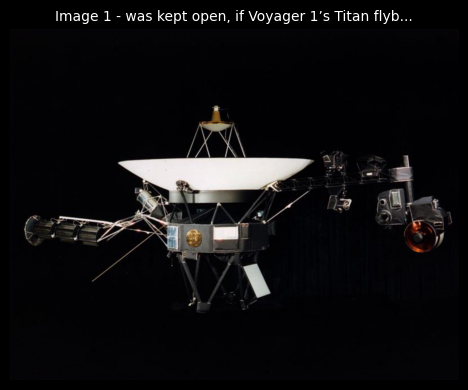

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 2] ID: 2
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was this photograph considered a major engineering milestone even though the spacecraft was still relatively close to Earth by solar system standards?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1878 sec
  Image: 0.041 sec
  Total: 3.4151614000002155 sec

📝 Formatted Query: Why was this photograph considered a major engineering milestone even though the sp

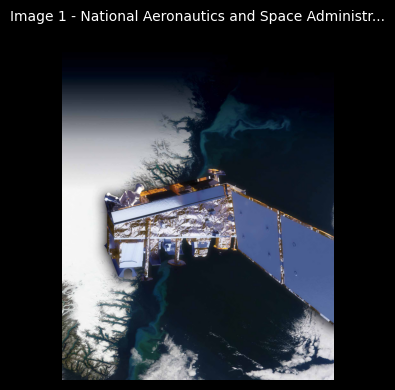

  Displayed image 1 (caption: National Aeronautics and Space Administration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 3] ID: 3
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1934 sec
  Image: 0.0459 sec
  Total: 2.4877568000010797 sec

📝 Formatted Query: What specific visual features in this montage support the claims of active volcanoes on Io and a possible subsurface ocean on Europa?

📄 T

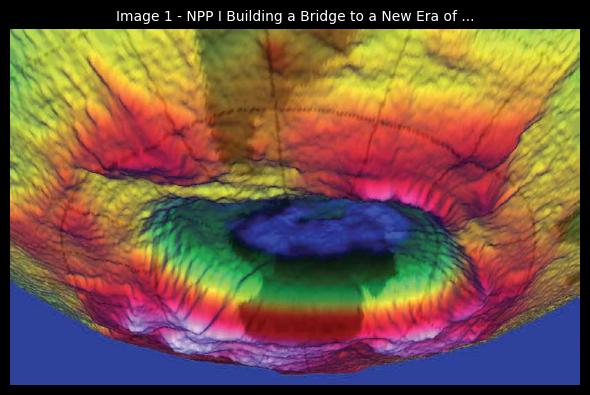

  Displayed image 1 (caption: NPP I Building a Bridge to a New Era of Earth Observations
11...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 4] ID: 4
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why did the mission team deliberately wait until just before permanently shutting down the cameras to capture this image, and what deeper message does it convey?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1895 sec
  Image: 0.0404 sec
  Total: 3.1569582000010996 sec

📝 Formatted Query: Why did the mission team deliberately wait until just before permanently shutting down the cam

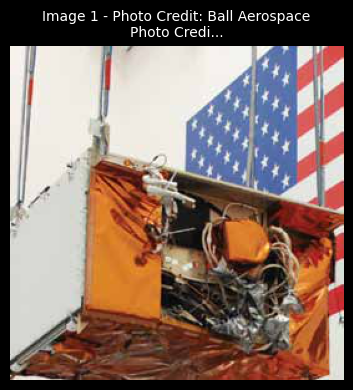

  Displayed image 1 (caption: Photo Credit: Ball Aerospace
Photo Credit: Ball Aerospace VIIRS is a multi-spect...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 5] ID: 5
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of years in the future?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1814 sec
  Image: 0.0418 sec
  Total: 3.1776212000004307 sec

📝 Formatted Query: Why was 1970s analog technology deliberately chosen for a message that might be found tens of thousands of ye

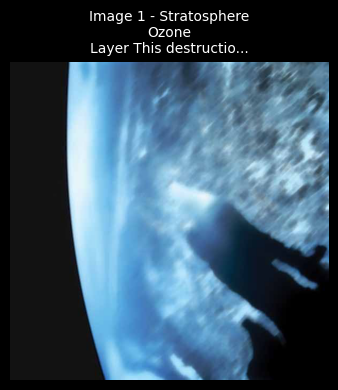

  Displayed image 1 (caption: Stratosphere
Ozone
Layer This destruction of the ozone layer is most extreme ove...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 6] ID: 6
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: What scientific trade-off led to Voyager 1's flyby permanently sacrificing all future planetary encounters while Voyager 2 was allowed to continue?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.2097 sec
  Image: 0.0351 sec
  Total: 2.677723999997397 sec

📝 Formatted Query: What scientific trade-off led to Voyager 1's flyby permanently sacrificing all future plan

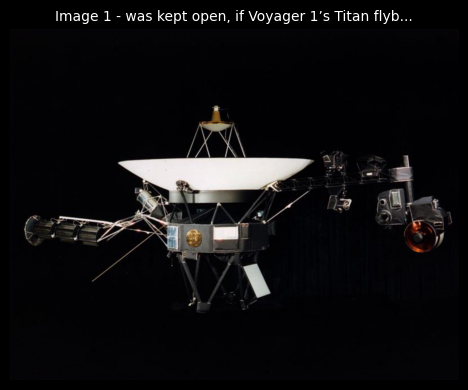

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 7] ID: 7
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why is it counterintuitive that Voyager 2 discovered more new moons at these distant ice giants than at Jupiter and Saturn combined, despite spending far less time observing them?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.2637 sec
  Image: 0.0358 sec
  Total: 2.318067299998802 sec

📝 Formatted Query: Why is it counterintuitive that Voyager 2 discovered more 

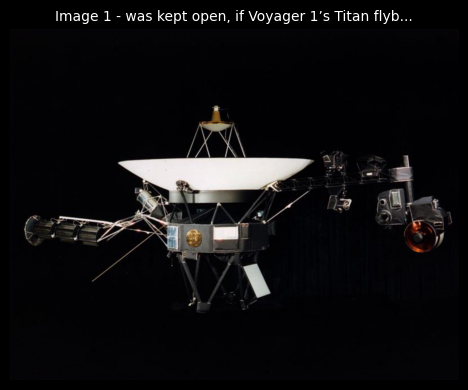

  Displayed image 1 (caption: was kept open, if Voyager 1’s Titan flyby was successful, to retarget Voyager 2 ...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 8] ID: 8
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How does the visible design explain why both spacecraft could still be operating after 45+ years when most missions are planned for only a few years?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1908 sec
  Image: 0.0383 sec
  Total: 3.0343683999999485 sec

📝 Formatted Query: How does the visible design explain why both spacecraft could still be operating after 

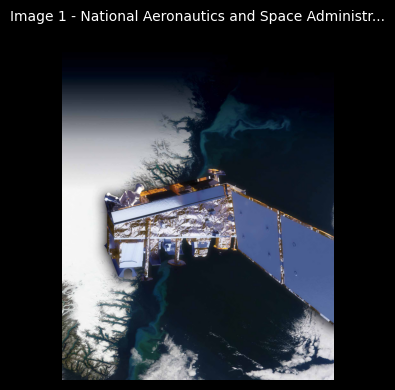

  Displayed image 1 (caption: National Aeronautics and Space Administration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 9] ID: 9
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Reconstruct the full ancient river system story and explain why this image alone was not sufficient to prove past habitability.
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1603 sec
  Image: 0.0357 sec
  Total: 2.854996399997617 sec

📝 Formatted Query: Reconstruct the full ancient river system story and explain why this image alone was not sufficient to prove past habitability.

📄 TEXT CONTEXT:


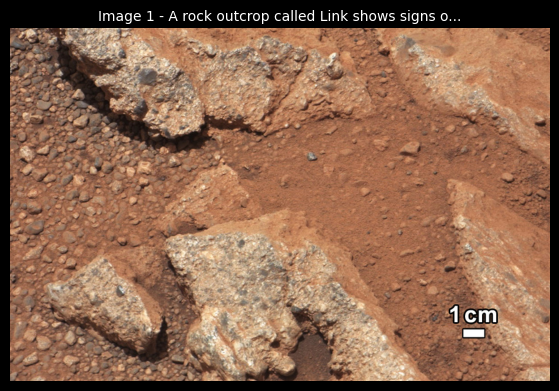

  Displayed image 1 (caption: A rock outcrop called Link shows signs of being formed by the deposition 
of wat...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 10] ID: 10
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was the 20 km landing precision improvement not just an engineering achievement but a fundamental prerequisite for the entire scientific mission?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1586 sec
  Image: 0.0365 sec
  Total: 2.924962400000368 sec

📝 Formatted Query: Why was the 20 km landing precision improvement not just an engineering achievement bu

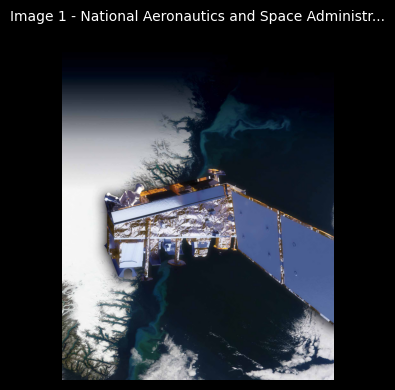

  Displayed image 1 (caption: National Aeronautics and Space Administration...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 11] ID: 11
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How was this image technically assembled, and what does it reveal about the rover's mobility and self-diagnostic capabilities?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1557 sec
  Image: 0.0352 sec
  Total: 2.9662468999995326 sec

📝 Formatted Query: How was this image technically assembled, and what does it reveal about the rover's mobility and self-diagnostic capabilities?

📄 TEXT CONTEXT:

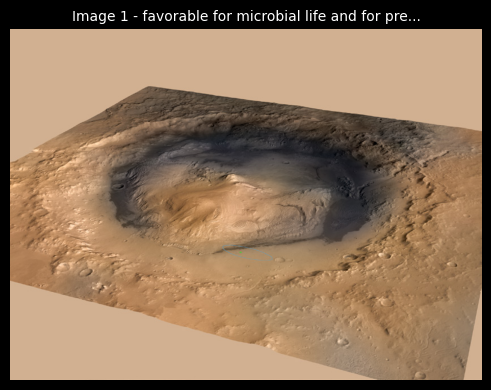

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 12] ID: 12
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: How does the powdered interior sample, combined with the 4.2 billion year age, create a paradox about geological preservation on Mars?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1828 sec
  Image: 0.0357 sec
  Total: 3.238761100001284 sec

📝 Formatted Query: How does the powdered interior sample, combined with the 4.2 billion year age, create a paradox about

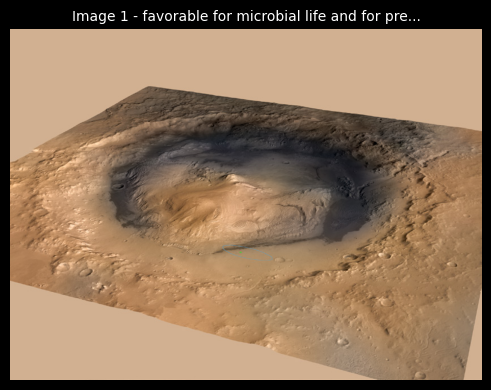

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 13] ID: 13
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was the documented decline in radioisotope power from 110W to 100W over two years actually a positive indicator for long-term mission success?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.2379 sec
  Image: 0.0402 sec
  Total: 3.3750464000004285 sec

📝 Formatted Query: Why was the documented decline in radioisotope power from 110W to 100W over two years ac

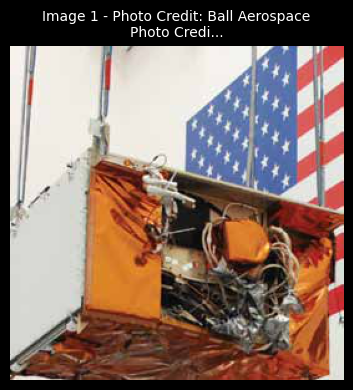

  Displayed image 1 (caption: Photo Credit: Ball Aerospace
Photo Credit: Ball Aerospace VIIRS is a multi-spect...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 14] ID: 14
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why does the document argue that visual imaging alone could never have proven past habitability, and what hierarchical chain of instruments was required?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.155 sec
  Image: 0.0361 sec
  Total: 3.134019499997521 sec

📝 Formatted Query: Why does the document argue that visual imaging alone could never have proven past 

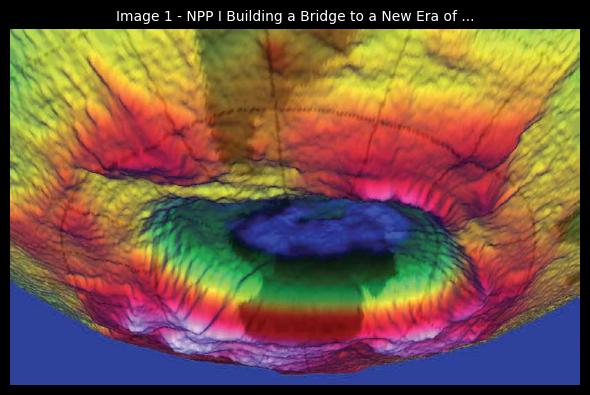

  Displayed image 1 (caption: NPP I Building a Bridge to a New Era of Earth Observations
11...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------------------------------------------------------------------
[Question 15] ID: 15
----------------------------------------------------------------------------------------------------------------------------------------------------------------
Query: Why was Gale Crater chosen over dozens of other sites, and how did the payload directly address the habitability question?
Expected Images: True

⏱️ Retrieval Timings:
  Text:  0.1562 sec
  Image: 0.0345 sec
  Total: 2.8995705999986967 sec

📝 Formatted Query: Why was Gale Crater chosen over dozens of other sites, and how did the payload directly address the habitability question?

📄 TEXT 

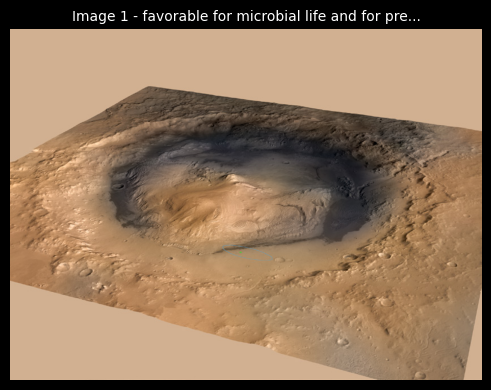

  Displayed image 1 (caption: favorable for microbial life and for preserving clues in the rocks about possibl...)

----------------------------------------------------------------------------------------------------------------------------------------------------------------




In [36]:
display_formatted_results(retrieval_output, formatter)